# Trend Rigidity Sensitivity

This notebook compares state-space specifications with different trend rigidity. The goal is not to replace the main analysis immediately, but to check whether COVID-period coefficients, the post-statistical-connection dummy, and decomposition results depend strongly on the flexibility of the trend.

This first implementation is limited to modeling comparison. It does not run forecast evaluation, does not update model-comparison tables, and does not include TR3, SARIMA, Prophet, Autoformer, or NeuralForecast.

## 1. Specifications

All specifications use the connected monthly parcel-volume series, log target `y`, monthly seasonal state component, and the same `baseline_m4` event dummies.

| spec_id | trend definition | interpretation |
|---|---|---|
| `TR0_local_linear` | local linear trend with level and slope disturbances | Existing main-analysis SSM, corresponding to `baseline_m4`. |
| `TR1_fixed_slope` | local linear trend with slope disturbance removed from the selection matrix | Existing fixed-slope SSM, corresponding to `fixed_slope_m4`. |
| `TR2_deterministic_linear` | deterministic linear regression trend plus seasonal state and exogenous dummies | Hard trend comparison specification. |

For TR2, the trend component is explicitly computed as:

```text
intercept + time_slope * time_index_centered
```

TR2 has a different state structure from TR0/TR1. AIC/BIC are still reported, but they should not be used alone to choose the main specification.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_connected_parcel_data
from src.features import add_period_dummies
from src.forecasting.forecast_specs import get_forecast_spec
from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog

DATA_PATH = ROOT / "data" / "processed" / "parcel_volume_connected.csv"
SENSITIVITY_DIR = ROOT / "output" / "sensitivity"
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_PATH = SENSITIVITY_DIR / "trend_rigidity_model_comparison.csv"
COEFFICIENTS_PATH = SENSITIVITY_DIR / "trend_rigidity_coefficients.csv"
DIAGNOSTICS_PATH = SENSITIVITY_DIR / "trend_rigidity_diagnostics.csv"
FIT_SUMMARY_PATH = SENSITIVITY_DIR / "trend_rigidity_fit_summary.csv"
MAIN_FIGURE_PATH = SENSITIVITY_DIR / "trend_rigidity_decomposition_main.png"
SEASONAL_FIGURE_PATH = SENSITIVITY_DIR / "trend_rigidity_decomposition_seasonal.png"
EXOG_FIGURE_PATH = SENSITIVITY_DIR / "trend_rigidity_decomposition_exog.png"
RESIDUAL_FIGURE_PATH = SENSITIVITY_DIR / "trend_rigidity_decomposition_residuals.png"
TREND_ZOOM_PATH = SENSITIVITY_DIR / "trend_rigidity_trends_zoom.png"


## 2. Load Data And baseline_m4 Dummies

The exogenous variables match `baseline_m4`: `hike_dummy`, `covid_main`, `covid_wave1`, `covid_2021`, and `post_stat_change`. Variables that are constant over the full modeling sample would be dropped, but in the connected full sample all five are expected to vary.

In [2]:
df = load_connected_parcel_data(DATA_PATH)
df.index = pd.to_datetime(df.index).to_period("M").to_timestamp()
spec = get_forecast_spec("baseline_m4")
exog_periods = spec["exog_periods"]
df = add_period_dummies(df, exog_periods)

ALL_EXOG_NAMES = list(exog_periods.keys())
used_exog_cols = [name for name in ALL_EXOG_NAMES if df[name].nunique(dropna=True) > 1]
dropped_exog_cols = [name for name in ALL_EXOG_NAMES if name not in used_exog_cols]
EXOG_NAMES = used_exog_cols

df["time_index"] = np.arange(len(df), dtype=float)
df["time_index_centered"] = df["time_index"] - df["time_index"].mean()

exog_summary = pd.DataFrame(
    [
        {
            "exog": name,
            "active_months": int(df[name].sum()),
            "unique_values": str(sorted(df[name].dropna().unique().tolist())),
            "decision": "used" if name in used_exog_cols else "dropped: constant over modeling sample",
        }
        for name in ALL_EXOG_NAMES
    ]
)

pd.DataFrame(
    [
        {
            "start": df.index.min().strftime("%Y-%m-%d"),
            "end": df.index.max().strftime("%Y-%m-%d"),
            "nobs": len(df),
            "used_exog_cols": ",".join(used_exog_cols),
            "dropped_exog_cols": ",".join(dropped_exog_cols),
        }
    ]
)


,start,end,nobs,used_exog_cols,dropped_exog_cols
0,2002-04-01,2026-02-01,287,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",


In [3]:
exog_summary

,exog,active_months,unique_values,decision
0,hike_dummy,27,"[0, 1]",used
1,covid_main,39,"[0, 1]",used
2,covid_wave1,2,"[0, 1]",used
3,covid_2021,9,"[0, 1]",used
4,post_stat_change,43,"[0, 1]",used


## 3. Model Definitions

TR0 reuses the existing main-analysis local-linear-trend SSM class from `src.ssm_models`. TR1 and TR2 are local definitions inside this notebook. TR1 matches the existing fixed-slope definition: the slope state is retained, but slope disturbance is removed from the selection matrix. TR2 is a deterministic linear trend regression plus seasonal state and exogenous dummies.

In [4]:
class LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    # Local linear trend + seasonal + exog, with slope disturbance fixed at zero.

    def __init__(self, endog, exog_list, param_names, seasonal_period=12, **kwargs):
        self.k_seasonal = seasonal_period
        k_states = 2 + (self.k_seasonal - 1)
        k_posdef = 2
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)

        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization="diffuse", **kwargs)

        self.ssm["design"] = np.zeros((1, k_states))
        self.ssm["design", 0, 0] = 1
        self.ssm["design", 0, 2] = 1

        transition = np.zeros((k_states, k_states))
        transition[0, 0] = 1
        transition[0, 1] = 1
        transition[1, 1] = 1
        transition[2, 2:] = -1
        for i in range(3, k_states):
            transition[i, i - 1] = 1
        self.ssm["transition"] = transition

        selection = np.zeros((k_states, k_posdef))
        selection[0, 0] = 1
        selection[2, 1] = 1
        self.ssm["selection"] = selection

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm["obs_intercept"] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        constrained = unconstrained.copy()
        constrained[:3] = constrained[:3] ** 2
        return constrained

    def untransform_params(self, constrained):
        unconstrained = constrained.copy()
        unconstrained[:3] = np.sqrt(unconstrained[:3])
        return unconstrained

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]
        self["state_cov", 0, 0] = params[1]
        self["state_cov", 1, 1] = params[2]

        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[3 + i] * self.exogs[i]
        self["obs_intercept", 0, :] = total_exog_effect


class DeterministicLinearTrendSeasonalWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    # Deterministic linear trend regression + seasonal state + fixed exog effects.

    def __init__(self, endog, time_index_centered, exog_list, param_names, seasonal_period=12, **kwargs):
        self.k_seasonal = seasonal_period
        k_states = self.k_seasonal - 1
        k_posdef = 1
        self.param_names_custom = param_names
        self.time_index_centered = np.asarray(time_index_centered, dtype=float).reshape(1, -1)
        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.num_exog = len(exog_list)

        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization="diffuse", **kwargs)

        self.ssm["design"] = np.zeros((1, k_states))
        self.ssm["design", 0, 0] = 1

        transition = np.zeros((k_states, k_states))
        transition[0, :] = -1
        for i in range(1, k_states):
            transition[i, i - 1] = 1
        self.ssm["transition"] = transition

        selection = np.zeros((k_states, k_posdef))
        selection[0, 0] = 1
        self.ssm["selection"] = selection
        self.ssm["obs_intercept"] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        constrained = unconstrained.copy()
        constrained[:2] = constrained[:2] ** 2
        return constrained

    def untransform_params(self, constrained):
        unconstrained = constrained.copy()
        unconstrained[:2] = np.sqrt(unconstrained[:2])
        return unconstrained

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]
        self["state_cov", 0, 0] = params[1]

        total_effect = params[2] + params[3] * self.time_index_centered
        for i in range(self.num_exog):
            total_effect += params[4 + i] * self.exogs[i]
        self["obs_intercept", 0, :] = total_effect


## 4. Fit TR0/TR1/TR2

All three specifications are re-estimated in this notebook so that tables and figures are generated in a common format. Failures or convergence warnings are recorded in the output tables rather than silently ignored.

In [5]:
TR0_BASE_PARAMS = ["obs_noise", "level_noise", "slope_noise", "seasonal_noise"]
TR1_BASE_PARAMS = ["obs_noise", "level_noise", "seasonal_noise"]
TR2_BASE_PARAMS = ["obs_noise", "seasonal_noise", "intercept", "time_slope"]
COEFF_START_HINTS = {"covid_main": -2.0, "covid_wave1": -2.0, "covid_2021": -3.0}


def make_param_names(base_params: list[str], exog_names: list[str]) -> list[str]:
    return base_params + [f"{name}_effect" for name in exog_names]


def build_start_params(spec_id: str, base_params: list[str], exog_names: list[str]) -> list[float]:
    if spec_id == "TR0_local_linear":
        init_base = [0.01, 0.01, 0.001, 0.001]
    elif spec_id == "TR1_fixed_slope":
        init_base = [0.01, 0.01, 0.001]
    elif spec_id == "TR2_deterministic_linear":
        init_base = [0.01, 0.001, float(df["y"].mean()), 0.0]
    else:
        raise ValueError(f"Unknown spec_id: {spec_id}")
    init_coeffs = [COEFF_START_HINTS.get(name, 0.0) for name in exog_names]
    return init_base + init_coeffs


def fit_one_spec(spec_id: str, model_class, base_params: list[str]) -> dict:
    param_names = make_param_names(base_params, EXOG_NAMES)
    exog_data = [df[name] for name in EXOG_NAMES]
    kwargs = {
        "endog": df["y"].astype(float),
        "exog_list": exog_data,
        "param_names": param_names,
        "seasonal_period": 12,
    }
    if spec_id == "TR2_deterministic_linear":
        kwargs["time_index_centered"] = df["time_index_centered"].to_numpy(dtype=float)

    model = model_class(**kwargs)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = model.fit(
            start_params=build_start_params(spec_id, base_params, EXOG_NAMES),
            maxiter=1000,
            disp=False,
        )

    convergence_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]
    warning_messages = [str(w.message) for w in caught]
    return {
        "spec_id": spec_id,
        "status": "success",
        "error": "",
        "result": result,
        "param_names": param_names,
        "convergence_warning": bool(convergence_warnings),
        "warning_messages": warning_messages,
    }


spec_definitions = {
    "TR0_local_linear": {
        "model_class": LocalLinearTrendSeasonalWithMultiFixedExog,
        "base_params": TR0_BASE_PARAMS,
        "trend_definition": "local linear trend with level and slope disturbances",
        "implementation_note": "Existing main-analysis SSM structure, equivalent to baseline_m4.",
    },
    "TR1_fixed_slope": {
        "model_class": LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog,
        "base_params": TR1_BASE_PARAMS,
        "trend_definition": "local linear trend with slope disturbance fixed at zero",
        "implementation_note": "Slope state retained; slope disturbance removed from selection matrix.",
    },
    "TR2_deterministic_linear": {
        "model_class": DeterministicLinearTrendSeasonalWithMultiFixedExog,
        "base_params": TR2_BASE_PARAMS,
        "trend_definition": "deterministic linear regression trend plus seasonal state",
        "implementation_note": "Trend is intercept + time_slope * time_index_centered; AIC/BIC should be interpreted cautiously because the state structure differs.",
    },
}

outputs = {}
for spec_id, definition in spec_definitions.items():
    try:
        outputs[spec_id] = fit_one_spec(
            spec_id,
            definition["model_class"],
            definition["base_params"],
        )
    except Exception as exc:
        outputs[spec_id] = {
            "spec_id": spec_id,
            "status": "failed",
            "error": str(exc),
            "result": None,
            "param_names": make_param_names(definition["base_params"], EXOG_NAMES),
            "convergence_warning": False,
            "warning_messages": [],
        }

pd.DataFrame(
    [
        {
            "spec_id": spec_id,
            "status": output["status"],
            "error": output["error"],
            "convergence_warning": output["convergence_warning"],
        }
        for spec_id, output in outputs.items()
    ]
)


,spec_id,status,error,convergence_warning
0,TR0_local_linear,success,,False
1,TR1_fixed_slope,success,,False
2,TR2_deterministic_linear,success,,True


## 5. Components, Tables, And Diagnostics

Residuals are computed consistently as `observed - fitted`. For TR2, the trend component is explicitly computed from the deterministic linear term.

In [6]:
def params_to_map(output: dict) -> dict[str, float]:
    result = output["result"]
    if result is None:
        return {}
    return dict(zip(output["param_names"], np.asarray(result.params, dtype=float)))


def compute_components(output: dict) -> dict | None:
    result = output["result"]
    if result is None:
        return None

    spec_id = output["spec_id"]
    param_map = params_to_map(output)
    states = np.asarray(result.smoother_results.smoothed_state, dtype=float)

    if spec_id in {"TR0_local_linear", "TR1_fixed_slope"}:
        trend = states[0]
        seasonal = states[2]
    elif spec_id == "TR2_deterministic_linear":
        trend = param_map["intercept"] + param_map["time_slope"] * df["time_index_centered"].to_numpy(dtype=float)
        seasonal = states[0]
    else:
        raise ValueError(f"Unknown spec_id: {spec_id}")

    effects = {}
    total_exog_effect = np.zeros(len(df), dtype=float)
    for exog_name in EXOG_NAMES:
        effect = param_map[f"{exog_name}_effect"] * df[exog_name].to_numpy(dtype=float)
        effects[exog_name] = effect
        total_exog_effect += effect

    fitted = trend + seasonal + total_exog_effect
    residual = df["y"].to_numpy(dtype=float) - fitted
    return {
        "trend": trend,
        "seasonal": seasonal,
        "effects": effects,
        "total_exog_effect": total_exog_effect,
        "fitted": fitted,
        "residual": residual,
    }


for output in outputs.values():
    output["components"] = compute_components(output)


def model_comparison_row(output: dict) -> dict:
    result = output["result"]
    spec_id = output["spec_id"]
    retvals = getattr(result, "mle_retvals", {}) or {} if result is not None else {}
    return {
        "spec_id": spec_id,
        "status": output["status"],
        "error": output["error"],
        "converged": retvals.get("converged", np.nan),
        "warnflag": retvals.get("warnflag", np.nan),
        "convergence_warning": output["convergence_warning"],
        "nobs": int(result.nobs) if result is not None else np.nan,
        "log_likelihood": float(result.llf) if result is not None else np.nan,
        "aic": float(result.aic) if result is not None else np.nan,
        "bic": float(result.bic) if result is not None else np.nan,
        "used_exog_cols": ",".join(used_exog_cols),
        "dropped_exog_cols": ",".join(dropped_exog_cols),
    }


def coefficient_rows(output: dict) -> list[dict]:
    result = output["result"]
    if result is None:
        return []

    rows = []
    params = np.asarray(result.params, dtype=float)
    bse = np.asarray(result.bse, dtype=float)
    zvalues = np.asarray(result.zvalues, dtype=float)
    pvalues = np.asarray(result.pvalues, dtype=float)

    for term, estimate, se, z_value, p_value in zip(output["param_names"], params, bse, zvalues, pvalues):
        is_event_effect = term.endswith("_effect")
        rows.append(
            {
                "spec_id": output["spec_id"],
                "term": term,
                "estimate": float(estimate),
                "std_error": float(se),
                "z_value": float(z_value),
                "p_value": float(p_value),
                "effect_percent": float(np.exp(estimate) - 1.0) if is_event_effect else np.nan,
            }
        )
    return rows


def diagnostics_row(output: dict) -> dict:
    components = output.get("components")
    if components is None:
        return {
            "spec_id": output["spec_id"],
            "ljung_box_p_value_lag12": np.nan,
            "ljung_box_p_value_lag24": np.nan,
            "resid_mean": np.nan,
            "resid_std": np.nan,
            "resid_min": np.nan,
            "resid_max": np.nan,
        }

    residual = components["residual"]
    lb12 = acorr_ljungbox(residual, lags=[12], return_df=True)
    lb24 = acorr_ljungbox(residual, lags=[24], return_df=True)
    return {
        "spec_id": output["spec_id"],
        "ljung_box_p_value_lag12": float(lb12["lb_pvalue"].iloc[0]),
        "ljung_box_p_value_lag24": float(lb24["lb_pvalue"].iloc[0]),
        "resid_mean": float(np.mean(residual)),
        "resid_std": float(np.std(residual, ddof=1)),
        "resid_min": float(np.min(residual)),
        "resid_max": float(np.max(residual)),
    }


comparison_df = pd.DataFrame([model_comparison_row(output) for output in outputs.values()])
coefficients_df = pd.DataFrame([row for output in outputs.values() for row in coefficient_rows(output)])
diagnostics_df = pd.DataFrame([diagnostics_row(output) for output in outputs.values()])

fit_summary_df = pd.DataFrame(
    [
        {
            "spec_id": spec_id,
            "status": output["status"],
            "trend_definition": spec_definitions[spec_id]["trend_definition"],
            "implementation_note": spec_definitions[spec_id]["implementation_note"],
            "used_exog_cols": ",".join(used_exog_cols),
            "dropped_exog_cols": ",".join(dropped_exog_cols),
            "param_names": ",".join(output["param_names"]),
            "warning_messages": " | ".join(output["warning_messages"]),
        }
        for spec_id, output in outputs.items()
    ]
)

comparison_df


,spec_id,status,error,converged,warnflag,convergence_warning,nobs,log_likelihood,aic,bic,used_exog_cols,dropped_exog_cols
0,TR0_local_linear,success,,True,0,False,287,584.069437,-1124.138874,-1043.630265,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",
1,TR1_fixed_slope,success,,True,0,False,287,584.071011,-1126.142022,-1049.292896,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",
2,TR2_deterministic_linear,success,,False,2,True,287,531.004164,-1022.008328,-948.818684,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",


In [7]:
coefficients_df

,spec_id,term,estimate,std_error,z_value,p_value,effect_percent
0,TR0_local_linear,obs_noise,2.341110e-04,3.708879e-05,6.312176,2.751385e-10,NaN
1,TR0_local_linear,level_noise,7.401869e-05,1.788444e-05,4.138720,3.492485e-05,NaN
2,TR0_local_linear,slope_noise,2.255708e-11,1.768996e-08,0.001275,9.989826e-01,NaN
3,TR0_local_linear,seasonal_noise,5.364100e-05,1.407488e-05,3.811117,1.383400e-04,NaN
4,TR0_local_linear,hike_dummy_effect,-2.335149e-02,2.721449e-02,-0.858054,3.908629e-01,-0.023081
5,TR0_local_linear,covid_main_effect,3.046673e-02,1.864794e-02,1.633786,1.023038e-01,0.030936
6,TR0_local_linear,covid_wave1_effect,5.119621e-02,1.787219e-02,2.864574,4.175704e-03,0.052529
7,TR0_local_linear,covid_2021_effect,1.617967e-02,1.262663e-02,1.281392,2.000560e-01,0.016311
8,TR0_local_linear,post_stat_change_effect,-4.529941e-02,2.464215e-02,-1.838290,6.601972e-02,-0.044289
9,TR1_fixed_slope,obs_noise,2.340144e-04,3.691995e-05,6.338427,2.321223e-10,NaN


In [8]:
diagnostics_df

,spec_id,ljung_box_p_value_lag12,ljung_box_p_value_lag24,resid_mean,resid_std,resid_min,resid_max
0,TR0_local_linear,2.192728e-07,1.081990e-05,3.032804e-16,0.010720,-0.031998,0.047813
1,TR1_fixed_slope,2.193729e-07,1.077070e-05,6.808336e-17,0.010720,-0.032008,0.047821
2,TR2_deterministic_linear,6.787092e-72,2.694977e-71,5.312658e-05,0.027127,-0.073811,0.086715


In [9]:
fit_summary_df

,spec_id,status,trend_definition,implementation_note,used_exog_cols,dropped_exog_cols,param_names,warning_messages
0,TR0_local_linear,success,local linear trend with level and slope distur...,"Existing main-analysis SSM structure, equivale...","hike_dummy,covid_main,covid_wave1,covid_2021,p...",,"obs_noise,level_noise,slope_noise,seasonal_noi...",
1,TR1_fixed_slope,success,local linear trend with slope disturbance fixe...,Slope state retained; slope disturbance remove...,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",,"obs_noise,level_noise,seasonal_noise,hike_dumm...",
2,TR2_deterministic_linear,success,deterministic linear regression trend plus sea...,Trend is intercept + time_slope * time_index_c...,"hike_dummy,covid_main,covid_wave1,covid_2021,p...",,"obs_noise,seasonal_noise,intercept,time_slope,...",Maximum Likelihood optimization failed to conv...


## 6. Decomposition Figures

The figures compare observed values, fitted values, trend, seasonal component, exogenous effects, and residuals. The zoomed trend figure focuses on 2020 onward to inspect whether COVID-period movements are absorbed by the trend.

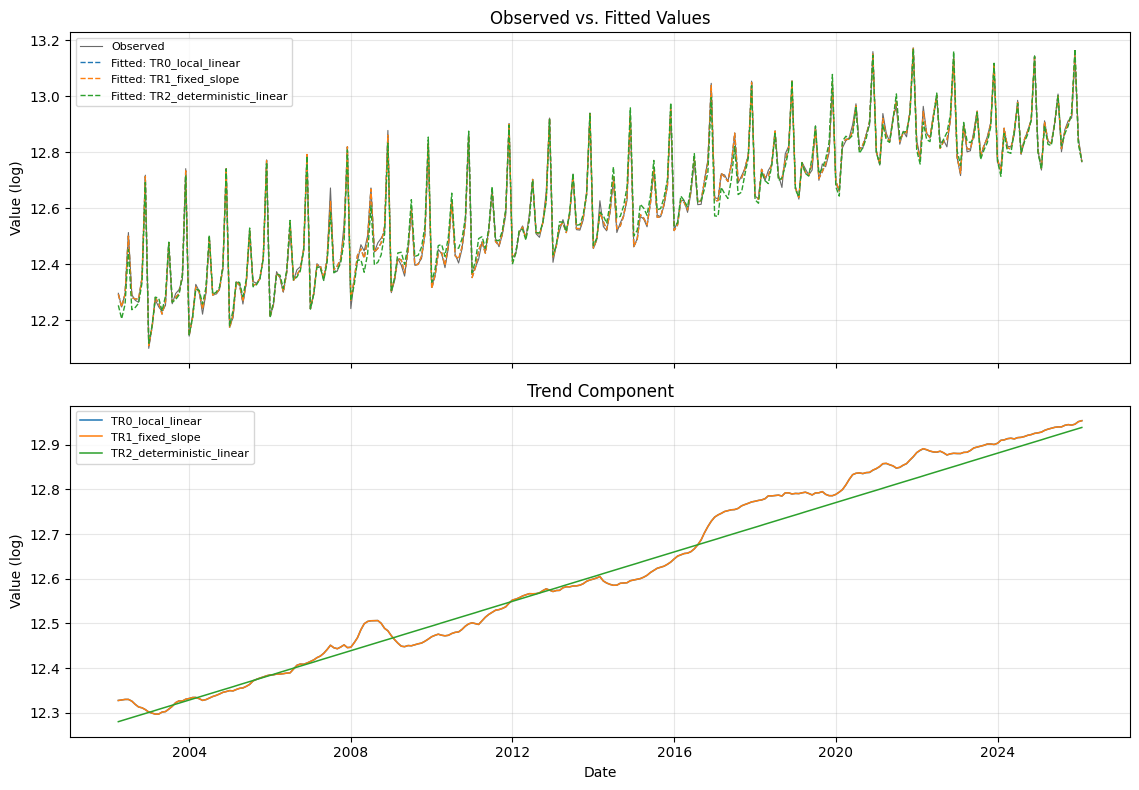

In [10]:
successful_spec_ids = [spec_id for spec_id, output in outputs.items() if output["status"] == "success"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11.5, 8), sharex=True)
axes[0].plot(df.index, df["y"], color="dimgray", linewidth=0.8, label="Observed")
for spec_id in successful_spec_ids:
    axes[0].plot(
        df.index,
        outputs[spec_id]["components"]["fitted"],
        linestyle="--",
        linewidth=1.0,
        label=f"Fitted: {spec_id}",
    )
axes[0].set_title("Observed vs. Fitted Values")
axes[0].set_ylabel("Value (log)")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.3)

for spec_id in successful_spec_ids:
    axes[1].plot(df.index, outputs[spec_id]["components"]["trend"], linewidth=1.1, label=spec_id)
axes[1].set_title("Trend Component")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value (log)")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(MAIN_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


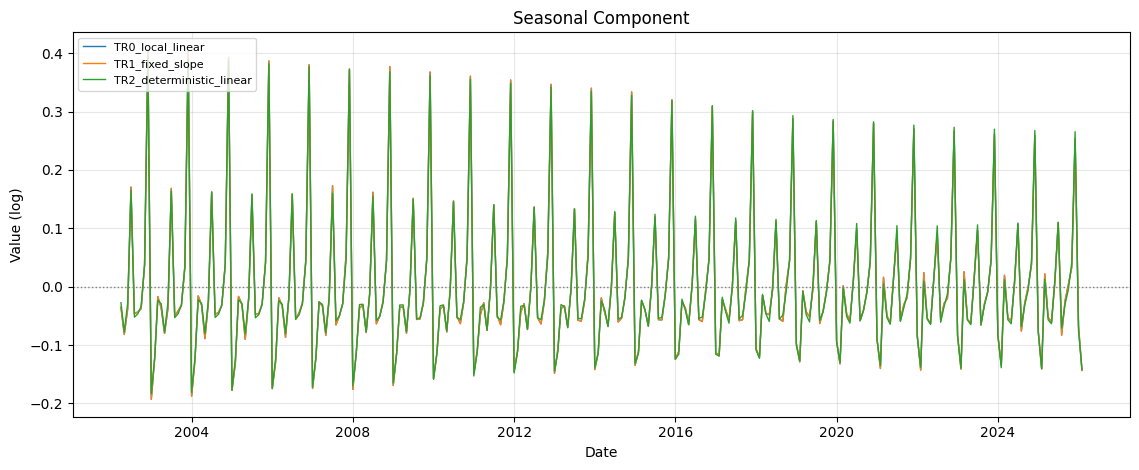

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
for spec_id in successful_spec_ids:
    ax.plot(df.index, outputs[spec_id]["components"]["seasonal"], linewidth=1.0, label=spec_id)
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Seasonal Component")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(SEASONAL_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


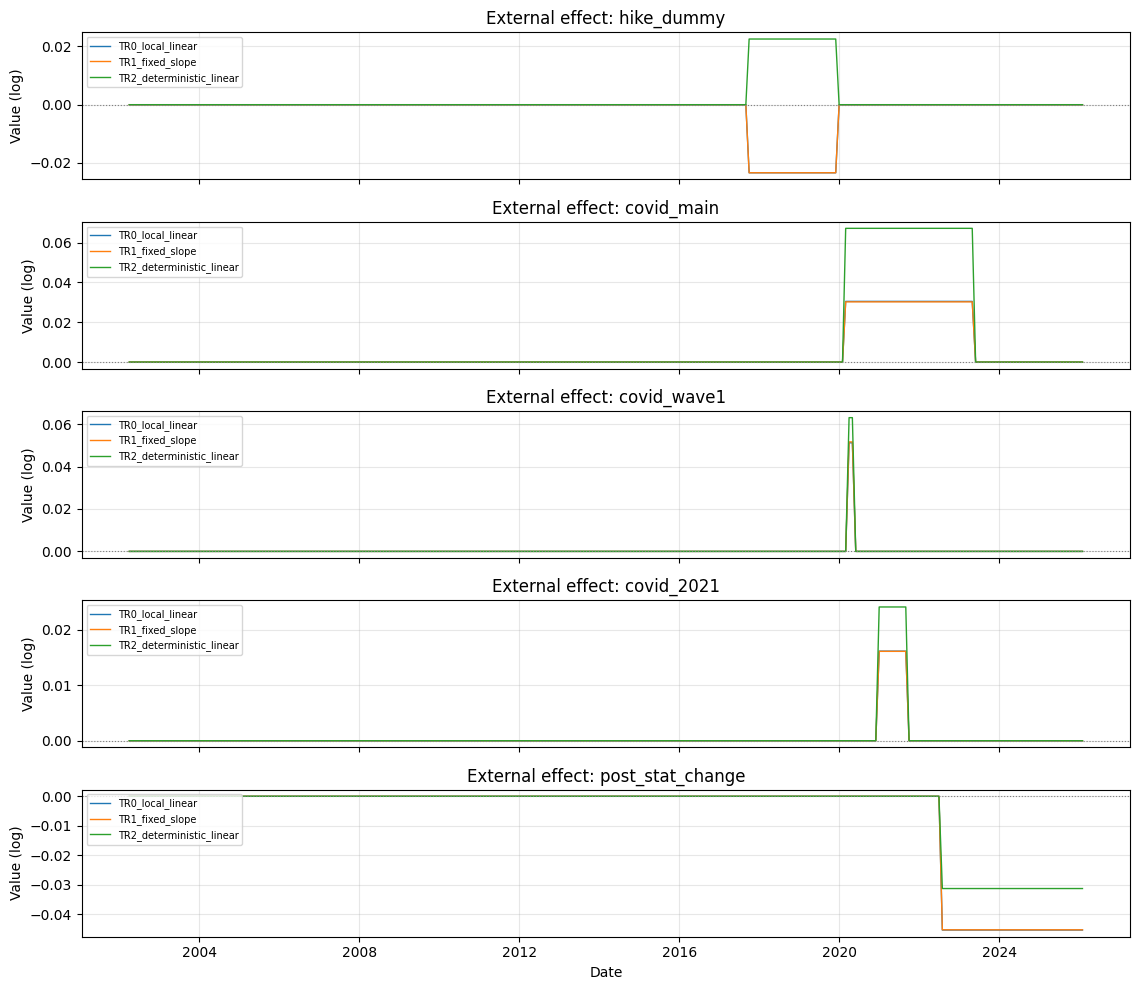

In [12]:
fig, axes = plt.subplots(nrows=len(EXOG_NAMES), ncols=1, figsize=(11.5, 10), sharex=True)
if len(EXOG_NAMES) == 1:
    axes = [axes]
for ax, exog_name in zip(axes, EXOG_NAMES):
    for spec_id in successful_spec_ids:
        ax.plot(df.index, outputs[spec_id]["components"]["effects"][exog_name], linewidth=1.0, label=spec_id)
    ax.axhline(y=0, color="grey", linestyle=":", linewidth=0.8)
    ax.set_title(f"External effect: {exog_name}")
    ax.set_ylabel("Value (log)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(EXOG_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


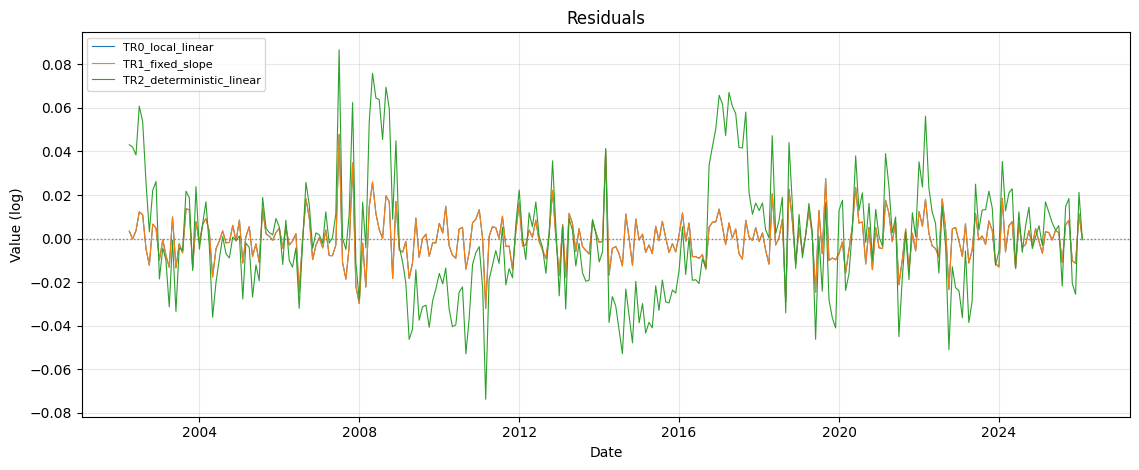

In [13]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
for spec_id in successful_spec_ids:
    ax.plot(df.index, outputs[spec_id]["components"]["residual"], linewidth=0.8, label=spec_id)
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(RESIDUAL_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


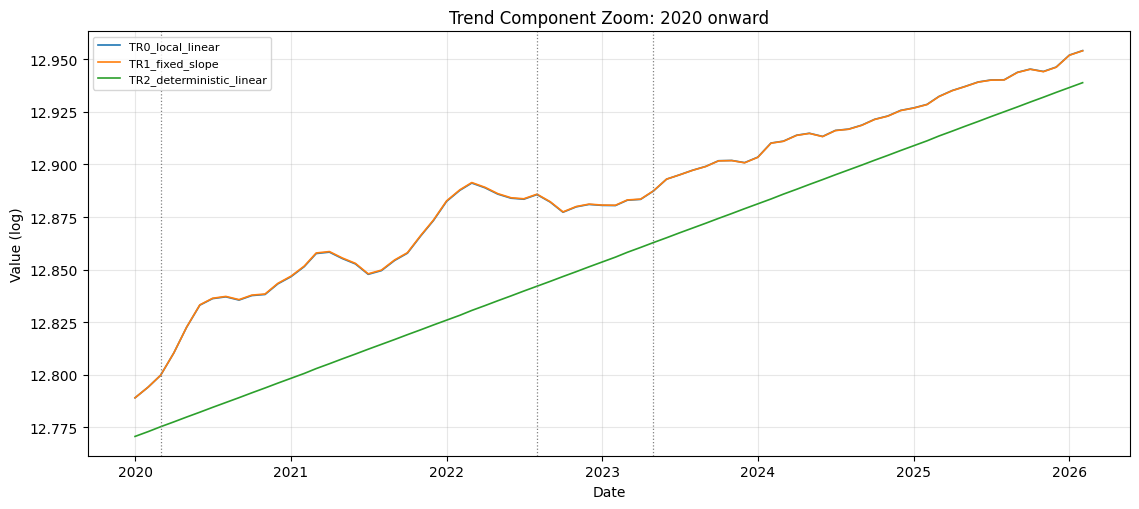

In [14]:
zoom_start = pd.Timestamp("2020-01-01")
fig, ax = plt.subplots(figsize=(11.5, 5.2))
for spec_id in successful_spec_ids:
    mask = df.index >= zoom_start
    ax.plot(df.index[mask], outputs[spec_id]["components"]["trend"][mask], linewidth=1.2, label=spec_id)
for date, label in [
    ("2020-03-01", "covid_main starts"),
    ("2022-08-01", "post_stat_change starts"),
    ("2023-05-01", "covid_main ends"),
]:
    ax.axvline(pd.Timestamp(date), color="grey", linestyle=":", linewidth=0.9)
ax.set_title("Trend Component Zoom: 2020 onward")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(TREND_ZOOM_PATH, dpi=300, bbox_inches="tight")
plt.show()


## 7. Save Outputs

The following files are newly created under `output/sensitivity/`. Existing fixed-slope outputs are not overwritten.

In [15]:
comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)
coefficients_df.to_csv(COEFFICIENTS_PATH, index=False)
diagnostics_df.to_csv(DIAGNOSTICS_PATH, index=False)
fit_summary_df.to_csv(FIT_SUMMARY_PATH, index=False)

for path in [
    MODEL_COMPARISON_PATH,
    COEFFICIENTS_PATH,
    DIAGNOSTICS_PATH,
    FIT_SUMMARY_PATH,
    MAIN_FIGURE_PATH,
    SEASONAL_FIGURE_PATH,
    EXOG_FIGURE_PATH,
    RESIDUAL_FIGURE_PATH,
    TREND_ZOOM_PATH,
]:
    print(f"saved {path}")


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_model_comparison.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_coefficients.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_diagnostics.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_fit_summary.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_decomposition_main.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_decomposition_seasonal.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_decomposition_exog.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\trend_rigidity_decomposition_residuals.png
saved

## 8. Reading Notes

- This notebook compares trend rigidity inside the SSM family only.
- TR2 is a deterministic linear trend regression plus seasonal state and exogenous dummies; it is not the same state structure as TR0/TR1.
- AIC/BIC are reported, but they should not be used alone to choose the main specification.
- The key question is whether `covid_main`, `covid_wave1`, `covid_2021`, and `post_stat_change` remain stable across trend specifications.
- This is a modeling comparison, not a forecast evaluation.
- TR3 local level, SARIMA differences, Prophet, Autoformer, and NeuralForecast are outside the scope of this first implementation.